In [1]:
import importlib
from tqdm.auto import tqdm
import os
import pickle
import sys
from pathlib import Path

os.environ['TOKENIZERS_PARALLELISM'] = 'false'
os.environ['CUDA_VISIBLE_DEVICES'] = '0'

parent_dir = Path(os.getcwd()).parent if Path(os.getcwd()).name == 'analysis' else Path(os.getcwd())
if str(parent_dir) not in sys.path:
    sys.path.insert(0, str(parent_dir))


import torch
import transformers
from transformers import AutoTokenizer, AutoModel
import numpy as np 
from torch.utils.data import DataLoader
from torch.cuda.amp import autocast

import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns
import pandas as pd

from safetensors.torch import load_model
from model import GenderChunkedClassifier

from eval_utils.viz_utils import plot_error_bar, plot_violins
from eval_utils.inference_utils import load_generated_output, find_threshold_for_N, calculate_metrics
from gender_dataset import MultiSpeciesGenderDataChunkedDataset

/disk/10tb/home/chepurova/miniconda3/envs/dna-lm/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
dump_file =  'mammals_model_runs_HUMAN_CONTIGS_human_contigs_16x3072_bs_128_lr_1e-05_chrY_from_checkpoint_run_1_checkpoint-50500_model.safetensors_train_species_Rattus rattus_force_Y_sampling_False_Y_ratio_None_X_ratio_None_30000_per_sample_142.pckl'

folder = '../mammals_inference_runs/human_model_runs/'

test_dump = os.path.join(folder, dump_file)


# test_sample2probs, test_sample2labels, test_sample2chromosomes = json.load([test_dump])
d = pickle.load(open(test_dump, 'rb'))
test_sample2probs, test_sample2labels, test_sample2chromosomes = d['sample_ids_probs'], d['sample_ids_labels'], d['sample_ids_sampled_chromosomes']

for k in test_sample2chromosomes:
    test_sample2chromosomes[k] = np.array(test_sample2chromosomes[k])

In [3]:
test_sample2probs['Rattus rattus']

array([[0.46875   ],
       [0.49609375],
       [0.47070312],
       ...,
       [0.49414062],
       [0.47265625],
       [0.48828125]], dtype=float32)

In [4]:
# new_test_sample2probs = {0: [], 1: []}
# new_test_sample2labels = {0: 0, 1: 1}
# new_test_sample2chromosomes =  {0: [], 1: []}
# for i in range(len(test_sample2probs)):
#     new_test_sample2probs[test_sample2labels[i]].append(test_sample2probs[i][0])
#     new_test_sample2chromosomes[test_sample2labels[i]].append(test_sample2chromosomes[i])

In [5]:
species = list(test_sample2probs.keys())[0]
new_test_sample2probs = {species+"_male": [], species+"_female": [] }
new_test_sample2chromosomes = {species+"_male": [], species+"_female": [] }
new_test_sample2labels = {species+"_male": 0, species+"_female": 1}


for i, elem in enumerate(test_sample2probs[species]):
    if test_sample2labels[species][i] == 0:
        new_test_sample2probs[species+"_male"].append(elem)
        new_test_sample2chromosomes[species+"_male"].append(test_sample2chromosomes[species][i])

    elif test_sample2labels[species][i] == 1:
        new_test_sample2probs[species+"_female"].append(elem)
        new_test_sample2chromosomes[species+"_female"].append(test_sample2chromosomes[species][i])

        
new_test_sample2probs

{'Rattus rattus_male': [array([0.46875], dtype=float32),
  array([0.4921875], dtype=float32),
  array([0.46289062], dtype=float32),
  array([0.46289062], dtype=float32),
  array([0.49804688], dtype=float32),
  array([0.48242188], dtype=float32),
  array([0.46679688], dtype=float32),
  array([0.47070312], dtype=float32),
  array([0.49414062], dtype=float32),
  array([0.49414062], dtype=float32),
  array([0.49414062], dtype=float32),
  array([0.49414062], dtype=float32),
  array([0.46875], dtype=float32),
  array([0.46875], dtype=float32),
  array([0.46484375], dtype=float32),
  array([0.5], dtype=float32),
  array([0.46679688], dtype=float32),
  array([0.49414062], dtype=float32),
  array([0.49414062], dtype=float32),
  array([0.47265625], dtype=float32),
  array([0.48046875], dtype=float32),
  array([0.46289062], dtype=float32),
  array([0.46875], dtype=float32),
  array([0.49804688], dtype=float32),
  array([0.48242188], dtype=float32),
  array([0.49414062], dtype=float32),
  array([0

In [6]:
new_test_sample2probs

{'Rattus rattus_male': [array([0.46875], dtype=float32),
  array([0.4921875], dtype=float32),
  array([0.46289062], dtype=float32),
  array([0.46289062], dtype=float32),
  array([0.49804688], dtype=float32),
  array([0.48242188], dtype=float32),
  array([0.46679688], dtype=float32),
  array([0.47070312], dtype=float32),
  array([0.49414062], dtype=float32),
  array([0.49414062], dtype=float32),
  array([0.49414062], dtype=float32),
  array([0.49414062], dtype=float32),
  array([0.46875], dtype=float32),
  array([0.46875], dtype=float32),
  array([0.46484375], dtype=float32),
  array([0.5], dtype=float32),
  array([0.46679688], dtype=float32),
  array([0.49414062], dtype=float32),
  array([0.49414062], dtype=float32),
  array([0.47265625], dtype=float32),
  array([0.48046875], dtype=float32),
  array([0.46289062], dtype=float32),
  array([0.46875], dtype=float32),
  array([0.49804688], dtype=float32),
  array([0.48242188], dtype=float32),
  array([0.49414062], dtype=float32),
  array([0

In [7]:
for key in new_test_sample2probs.keys():
    new_test_sample2probs[key] = np.array(new_test_sample2probs[key]).reshape(-1, 1)
for key in new_test_sample2chromosomes.keys():
    new_test_sample2chromosomes[key] = np.array(new_test_sample2chromosomes[key])


In [8]:
new_test_sample2chromosomes['Rattus rattus_female'].shape

(15055, 16, 3)

In [9]:
test_sample2probs = {sample: np.array(probs) for sample, probs in new_test_sample2probs.items()}

In [10]:
import matplotlib.ticker as ticker

def plot_error_bar(sample_ids_labels, Ns, accs, stds, X_probs, Y_probs, species_names, chrX_ratio, chrY_ratio):
    fig = plt.figure(figsize=(9, 15))  # Slightly taller figure
    gs = fig.add_gridspec(3, 1, height_ratios=[1, 1, 1], hspace=1)  # Increased spacing

    # Top plot: Accuracy with error bars
    ax1 = fig.add_subplot(gs[0, 0])
    ax1.errorbar(Ns, accs, yerr=stds, marker='o', linestyle='-', color='b', capsize=5)

    ax1.set_title('Accuracy vs Number of\nSampled Subsequences K', fontsize=22, fontweight='bold', pad=12)
    ax1.set_xlabel('# of Sampled Subsequences 16x3072bp (K)', fontsize=21, labelpad=3)
    ax1.set_ylabel('Accuracy', fontsize=21, labelpad=3)
    
    # More frequent horizontal grid lines, fewer Y-axis labels
    ax1.yaxis.set_major_locator(ticker.MultipleLocator(0.1))  # Show fewer Y-axis labels
    ax1.yaxis.set_minor_locator(ticker.MultipleLocator(0.1))  # Frequent grid lines

    ax1.set_xscale('log')
    ax1.set_xticks(Ns)
    ax1.set_xticklabels([str(n) for n in Ns], fontsize=16, rotation=45)
    ax1.tick_params(axis='y', labelsize=16)
    # ax1.grid(True,  which='both', linestyle='--')
    ax1.grid(axis='y', linestyle='--', alpha=0.7)
    ax1.grid(axis='x', linestyle='--', alpha=0.7)

    # Bottom plot: Y chromosome coverage
    ax2 = fig.add_subplot(gs[1, 0])
    bar_widths = [0.15 * n for n in Ns]
    Y_probs = np.array(Y_probs) * 100

    ax2.bar(Ns, Y_probs, width=bar_widths, color='orange', alpha=0.8)
    ax2.set_title('Average % of Y Chromosome Covered\nin Male Organisms vs. Sampled K', fontsize=22, fontweight='bold', pad=15)
    ax2.set_xlabel('# of Sampled Subsequences 16x3072bp (K)', fontsize=21, labelpad=3)
    ax2.set_ylabel('Avg. % of Y', fontsize=21, labelpad=1)

    # More frequent grid lines, but fewer labels on Y-axis
    ax2.yaxis.set_major_locator(ticker.MultipleLocator(20))  # Show labels at 0, 20, 40, ...
    ax2.yaxis.set_minor_locator(ticker.MultipleLocator(20))   # Grid lines every 5
    # ax2.grid(True, which='both', linestyle='--')
    ax2.grid(axis='y', linestyle='--', alpha=0.7)
    ax2.grid(axis='x', linestyle='--', alpha=0.7)

    ax2.set_xscale('log')
    ax2.set_xticks(Ns)
    ax2.set_xticklabels([str(n) for n in Ns], fontsize=16, rotation=45)
    ax2.tick_params(axis='y', labelsize=16)


    # Bottom right bar chart
    X_probs = np.array(X_probs) * 100
    ax3 = fig.add_subplot(gs[2, 0])
    ax3.bar(Ns, X_probs, width=bar_widths, color='green', alpha=0.8, align='center')
    ax3.set_title('Average % of X Chromosome Covered\nvs. Sampled K', fontsize=22, fontweight='bold', pad=15)
    ax3.set_xlabel('# of Sampled Subsequences 16x3072bp (K)', fontsize=21, labelpad=3)
    ax3.set_ylabel('Avg. % of X', fontsize=21, labelpad=1)

    ax3.yaxis.set_major_locator(ticker.MultipleLocator(20))  # Show labels at 0, 20, 40, ...
    ax3.yaxis.set_minor_locator(ticker.MultipleLocator(20))   # Grid lines every 5
    # ax2.grid(True, which='both', linestyle='--')
    ax3.grid(axis='y', linestyle='--', alpha=0.7)
    ax3.grid(axis='x', linestyle='--', alpha=0.7)

    ax3.set_xscale('log')
    ax3.set_xticks(Ns)
    ax3.set_xticklabels([str(n) for n in Ns], fontsize=16, rotation=45)
    ax3.tick_params(axis='y', labelsize=16)

    # Optimize layout for compactness while avoiding overlaps
    plt.tight_layout()
    plt.show()

def plot_violins(sample_ids_probs, sample_ids_labels, species_names, chrX_ratio, chrY_ratio):
    # Prepare DataFrame for plotting
    data_list = []
    for sample_id, probs in sample_ids_probs.items():
        # if sample_id in mouses_strains:
        # if sample_id in human_ids:

            for prob in probs:
                data_list.append({
                    'Sample ID': sample_id,  # Convert to string for consistent key usage
                    'Probability': prob[0],
                    'Label': "Female" if sample_ids_labels[sample_id] else "Male"
                })

    df = pd.DataFrame(data_list)

    # Sort data by label for plotting
    label_order = sorted(df['Label'].unique())
    sample_order = df.sort_values(by='Label')['Sample ID'].unique()

    # Plotting
    plt.figure(figsize=(15, 7))  # Adjusted size for better visibility
    # plt.suptitle(
    #     f"Analysis of Sampled Species: {", ".join(species_names)}\n"
    #     f"Sampling chromosome ratio of X: {chrX_ratio}\n"
    #     f"Sampling chromosome ratio of Y: {chrY_ratio}\n",
    #     fontsize=16,
    #     fontweight='bold',
    #     y=0.95,  # Adjust the vertical position of the title
    #     ha='center'
    # )

    plt.grid()
    ax = sns.violinplot(x='Sample ID', y='Probability', hue='Label', data=df, 
                        inner='box',
                        order=sample_order,
                        hue_order=label_order
                        )              
    # sns.stripplot(x='Sample ID', y='Probability', data=df, color='black', size=1, jitter=True, order=sample_order)

    plt.axhline(y=0.5, color='red', linestyle='--', linewidth=2)  # Add horizontal line at y=0.5

    # plt.title('Sex: 0 - M, 1 - F')
    plt.xticks(rotation=90)
    plt.xlabel('Sample ID', fontsize=16)
    plt.ylabel('Probability', fontsize=16)
    plt.legend(title='Label')
    plt.xticks(fontsize=12)
    plt.yticks(fontsize=12)

    # plt.tight_layout()
    plt.show()

## All species

In [11]:
labels_human_test = pd.read_csv("~/chepurova/human_data/test.csv")
labels_mouse_test = pd.read_csv("~/chepurova/mouse_data/test.csv")

labels_human_valid = pd.read_csv("~/chepurova/human_data/valid.csv")
labels_mouse_valid = pd.read_csv("~/chepurova/mouse_data/valid.csv")

labels_map = {1: 0, 2: 1, 'M': 0, 'F': 1}
labels_mouse_valid['gender'] = labels_mouse_valid['gender'].apply(lambda x: labels_map[x])
labels_mouse_test['gender'] = labels_mouse_test['gender'].apply(lambda x: labels_map[x])

labels_human_test['sex'] = labels_human_test['sex'].apply(lambda x: labels_map[x])
labels_human_valid['sex'] = labels_human_valid['sex'].apply(lambda x: labels_map[x])

mouses_strains = list(labels_mouse_test['strain_name']) + list(labels_mouse_valid['strain_name'])
human_ids = list(labels_human_valid['sample']) + list(labels_human_test['sample'])

In [12]:
probs = np.concatenate((new_test_sample2probs[species+'_male'], new_test_sample2probs[species+'_female'])).reshape(-1)
probs = probs > 0.5
labels = [0] * len(new_test_sample2probs[species+'_male'])  + [1]* len(new_test_sample2probs[species+'_female'])
from sklearn.metrics import accuracy_score
accuracy_score(y_pred=probs, y_true=labels)

0.49783333333333335

In [13]:
species_names = ['all']

N2thr = find_threshold_for_N(new_test_sample2labels, new_test_sample2probs, Ns=[25, 100, 1_000, 5_000, 15_000, 30_000])

In [14]:
new_test_sample2chromosomes

{'Rattus rattus_male': array([[['NC_046164.1 chromosome 11 _contig_17', '40820', '43892'],
         ['NC_046168.1 chromosome 15 _contig_13', '2112478', '2115550'],
         ['NC_046166.1 chromosome 13 _contig_106', '512062', '515134'],
         ...,
         ['NC_046170.1 chromosome 17 _contig_67', '6889467', '6892539'],
         ['NC_046156.1 chromosome 3 _contig_181', '1649554', '1652626'],
         ['NC_046167.1 chromosome 14 _contig_99', '10783110', '10786182']],
 
        [['NC_046161.1 chromosome 8 _contig_75', '3712', '6784'],
         ['NC_046158.1 chromosome 5 _contig_63', '543312', '546384'],
         ['NC_046156.1 chromosome 3 _contig_18', '350998', '354070'],
         ...,
         ['NC_046161.1 chromosome 8 _contig_128', '1978224', '1981296'],
         ['NC_046154.1 chromosome 1 _contig_231', '654548', '657620'],
         ['NC_046165.1 chromosome 12 _contig_74', '2082818', '2085890']],
 
        [['NC_046157.1 chromosome 4 _contig_57', '87004', '90076'],
         ['NC_0461

In [15]:
accs, stds, X_probs, Y_probs = calculate_metrics(new_test_sample2labels, new_test_sample2probs, new_test_sample2chromosomes, N2threshold=N2thr)

100%|██████████| 200/200 [00:52<00:00,  3.81it/s]


In [21]:
N2thr

{25: 0.0,
 100: 0.0,
 1000: 0.001,
 5000: 0.0008,
 15000: 0.0008,
 30000: 0.0008029441284710606}

In [16]:
for acc, std in zip(accs, stds):
    print(f'{acc}')

0.4925
0.475
0.395
0.185
0.0425
0.0525


In [ ]:
for acc, std in zip(accs, stds):
    print(f'{round(std, 2)}')


0.11
0.22
0.33
0.3
0.2
0.21


/tmp/ipykernel_1882674/1347137424.py:70: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


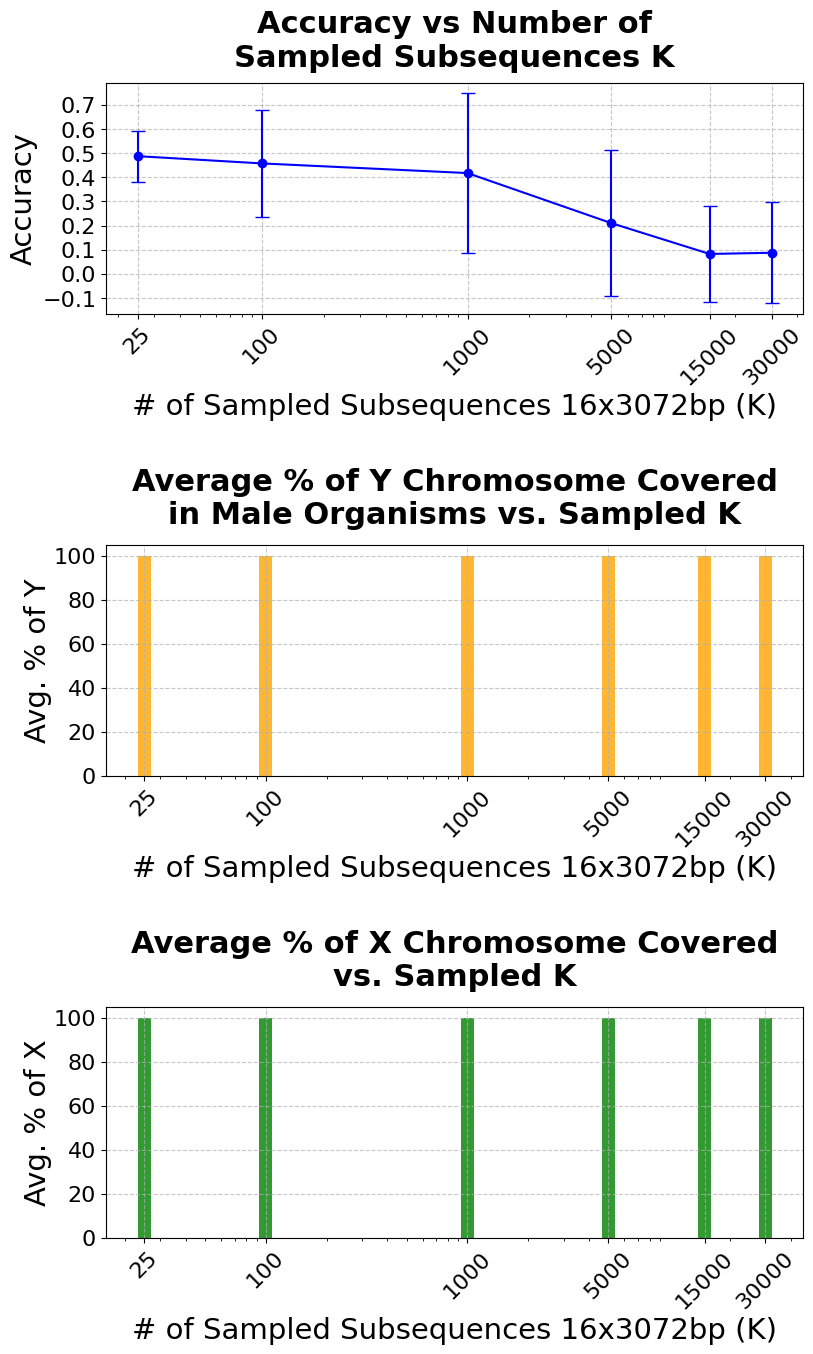

In [ ]:
plot_error_bar(new_test_sample2labels, list(N2thr.keys()), accs, stds, X_probs, Y_probs, species_names, X_probs, Y_probs)

In [ ]:
test_sample2chromosomes

{'Mus musculus': array([[['NC_000079.7 chromosome 13 _contig_2', '23109492', '23112564'],
         ['NC_000083.7 chromosome 17 _contig_5', '18889694', '18892766'],
         ['NC_000081.7 chromosome 15 _contig_0', '41694607', '41697679'],
         ...,
         ['NC_000084.7 chromosome 18 _contig_0', '72787398', '72790470'],
         ['NC_000070.7 chromosome 4 _contig_0', '4472336', '4475408'],
         ['NC_000082.7 chromosome 16 _contig_3', '18048805', '18051877']],
 
        [['NC_000068.8 chromosome 2 _contig_1', '122293386', '122296458'],
         ['NC_000080.7 chromosome 14 _contig_4', '50301304', '50304376'],
         ['NC_000070.7 chromosome 4 _contig_11', '21876567', '21879639'],
         ...,
         ['NC_000086.8 chromosome X _contig_49', '1228065', '1231137'],
         ['NC_000069.7 chromosome 3 _contig_4', '21431800', '21434872'],
         ['NC_000077.7 chromosome 11 _contig_1', '75981087', '75984159']],
 
        [['NC_000068.8 chromosome 2 _contig_1', '56435659', '564387

In [ ]:
plot_violins(valid_sample2probs, valid_sample2labels, species_names, chrX_ratio, chrY_ratio)

NameError: name 'valid_sample2probs' is not defined

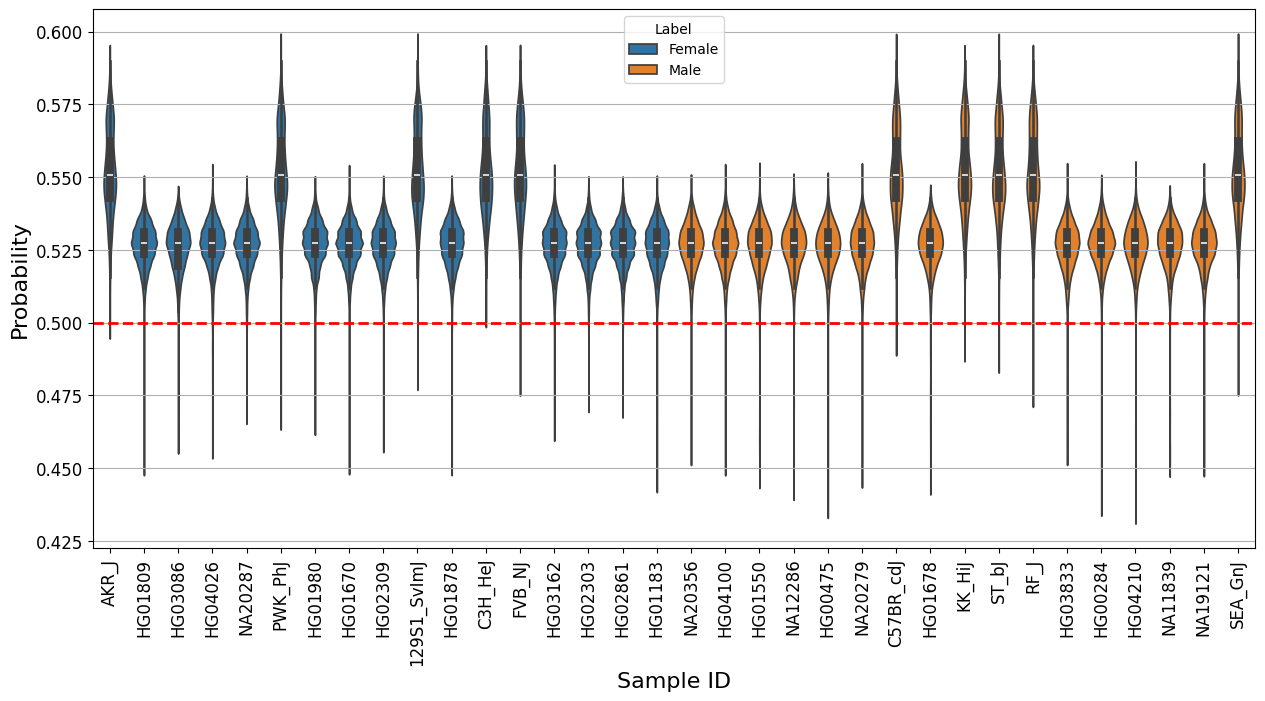

In [ ]:
plot_violins(test_sample2probs, test_sample2labels, species_names, chrX_ratio, chrY_ratio)

## Mice

In [44]:
species_names = ['mus_musculus']

sample_ids_mouses = {sample_id: label for sample_id, label in valid_sample2labels.items() if sample_id in mouses_strains}
N2thr = find_threshold_for_N(sample_ids_mouses, valid_sample2probs)
accs, stds, X_probs, Y_probs = calculate_metrics(sample_ids_mouses, valid_sample2probs, valid_sample2chromosomes, N2threshold=N2thr)

/tmp/ipykernel_2908020/1347137424.py:70: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


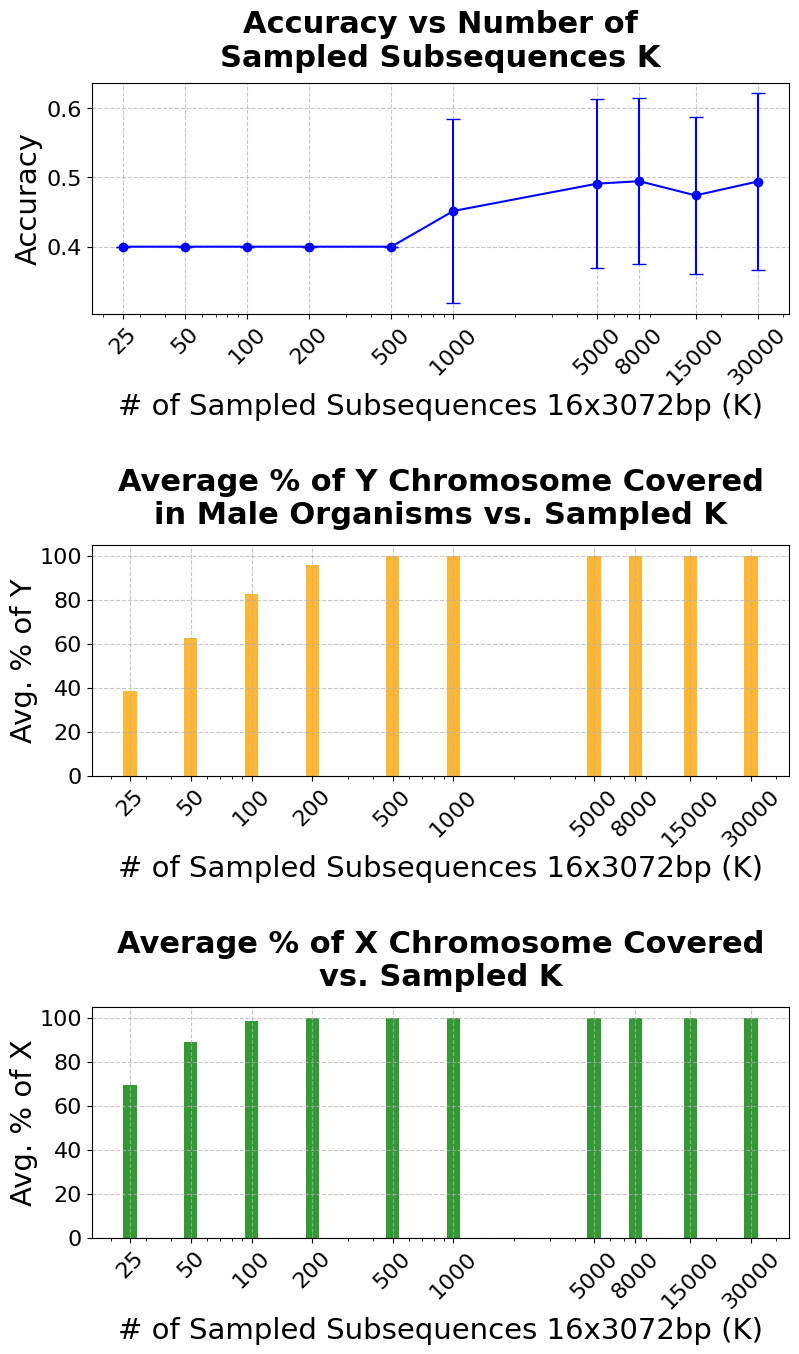

In [23]:
plot_error_bar(sample_ids_mouses, list(N2thr.keys()), accs, stds, X_probs, Y_probs, species_names, chrX_ratio, chrY_ratio)

/tmp/ipykernel_2908020/1347137424.py:70: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


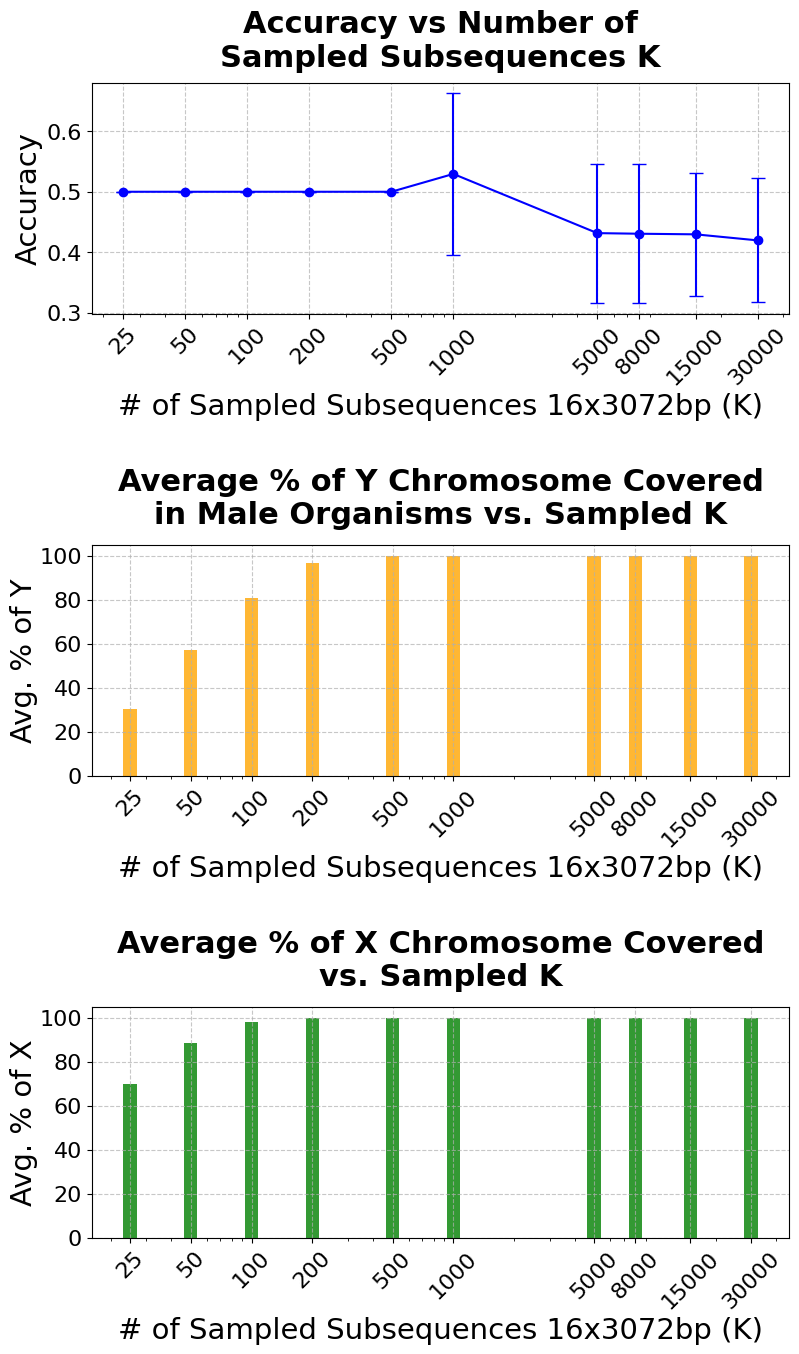

In [24]:
sample_ids_mouses = {sample_id: label for sample_id, label in test_sample2labels.items() if sample_id in mouses_strains}

accs, stds, X_probs, Y_probs = calculate_metrics(sample_ids_mouses, test_sample2probs, test_sample2chromosomes, N2threshold=N2thr)
plot_error_bar(sample_ids_mouses, list(N2thr.keys()), accs, stds, X_probs, Y_probs, species_names, chrX_ratio, chrY_ratio)

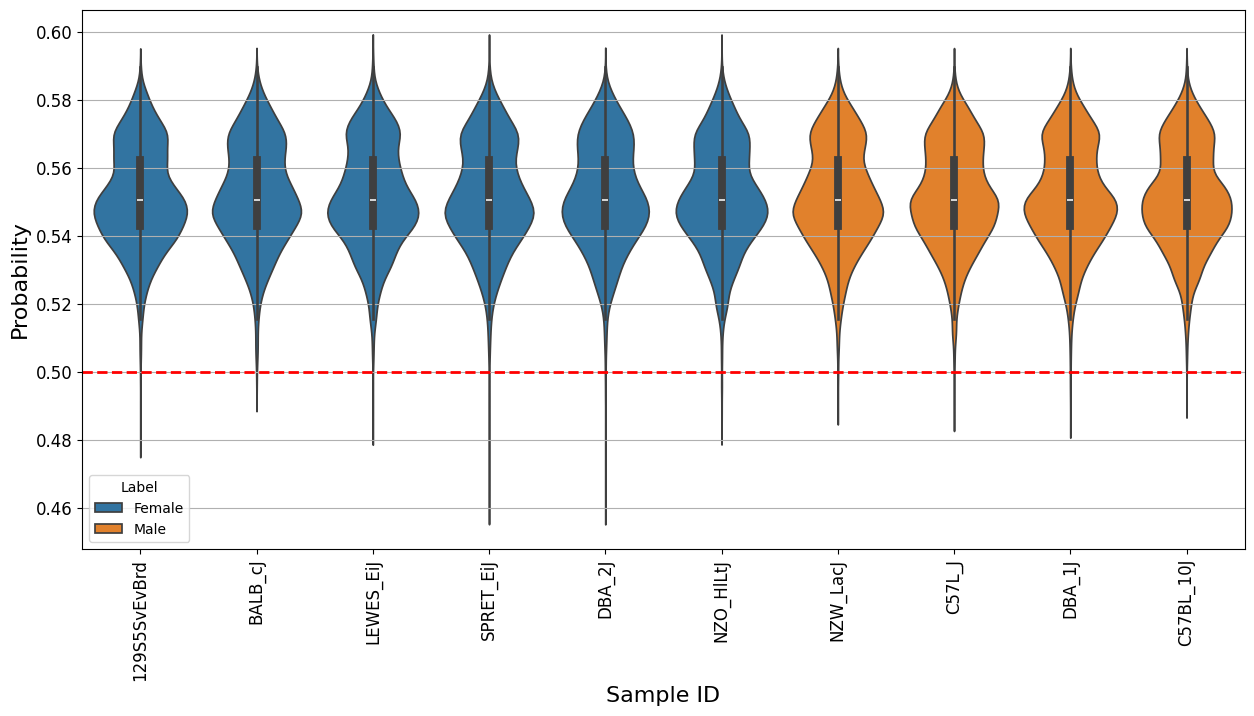

In [25]:
sample_ids_mouses = {sample_id: label for sample_id, label in valid_sample2labels.items() if sample_id in mouses_strains}
valid_sample2probs_mouses = {sample_id: prob for sample_id, prob in valid_sample2probs.items() if sample_id in mouses_strains}

plot_violins(valid_sample2probs_mouses, sample_ids_mouses, species_names, chrX_ratio, chrY_ratio)

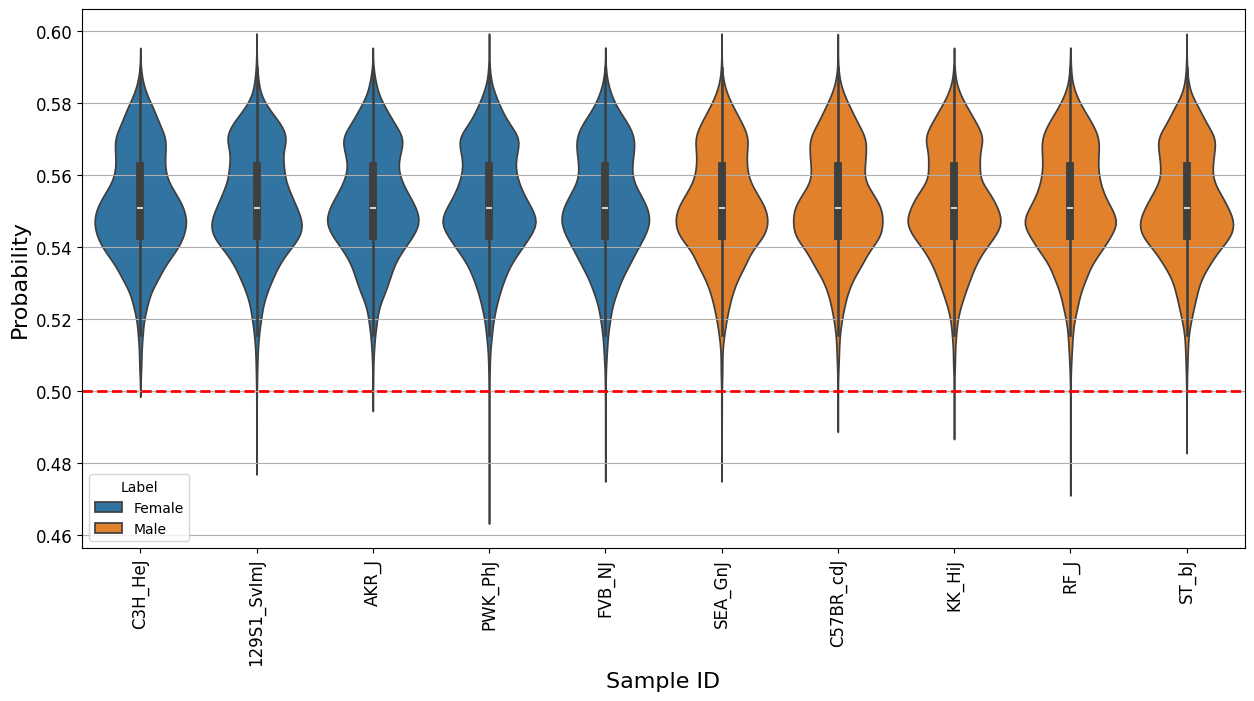

In [26]:
sample_ids_mouses = {sample_id: label for sample_id, label in test_sample2labels.items() if sample_id in mouses_strains}
test_sample2probs_mouses = {sample_id: prob for sample_id, prob in test_sample2probs.items() if sample_id in mouses_strains}

plot_violins(test_sample2probs_mouses, sample_ids_mouses, species_names, chrX_ratio, chrY_ratio)

## Humans

In [46]:
species_names = ['Homo_sapiens']
sample_ids_humans = {sample_id: label for sample_id, label in valid_sample2labels.items() if sample_id in human_ids}

N2thr = find_threshold_for_N(sample_ids_humans, valid_sample2probs)
accs, stds, X_probs, Y_probs = calculate_metrics(sample_ids_humans, valid_sample2probs, valid_sample2chromosomes, N2threshold=N2thr)

/tmp/ipykernel_2908020/1347137424.py:70: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


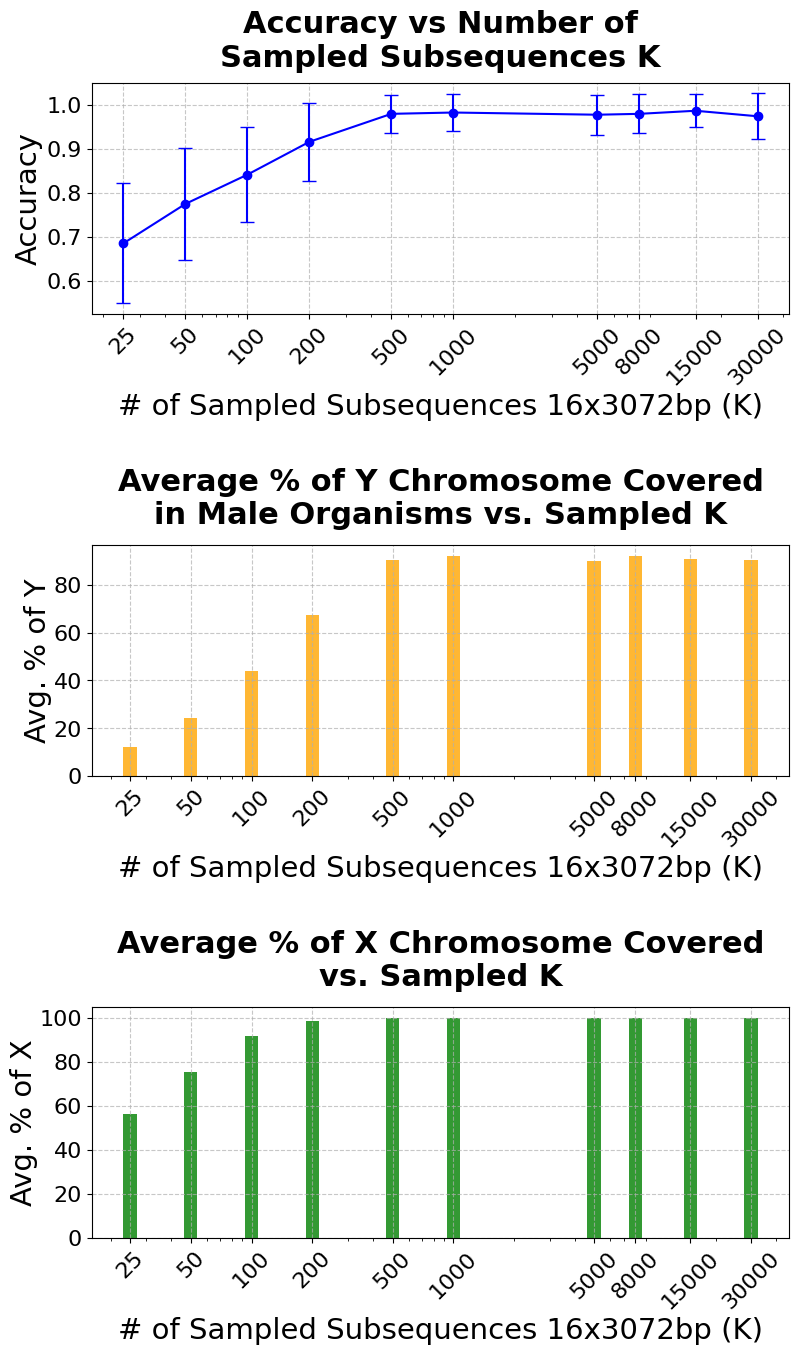

In [47]:
plot_error_bar(sample_ids_humans, list(N2thr.keys()), accs, stds, X_probs, Y_probs, species_names, chrX_ratio, chrY_ratio)

/tmp/ipykernel_2908020/1347137424.py:70: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


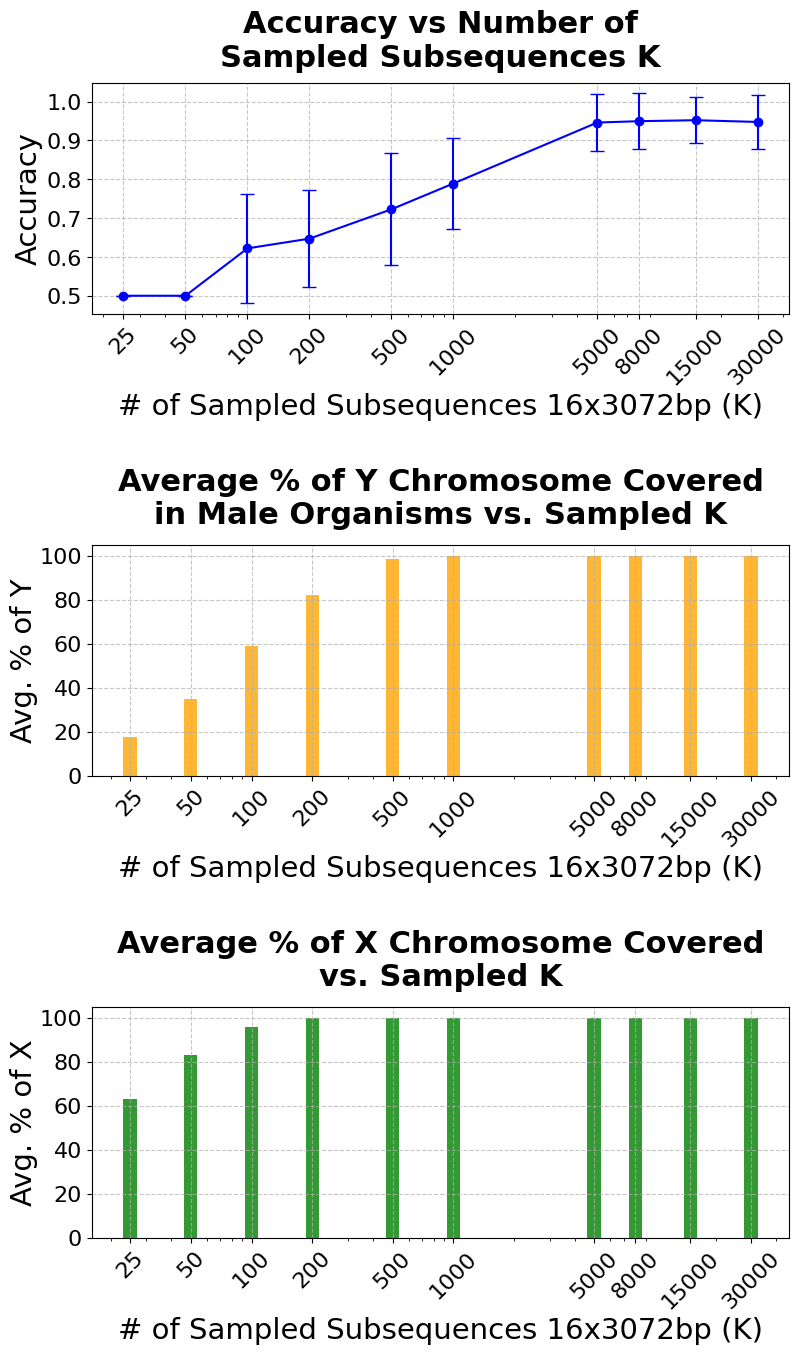

In [28]:
plot_error_bar(sample_ids_humans, list(N2thr.keys()), accs, stds, X_probs, Y_probs, species_names, chrX_ratio, chrY_ratio)

In [29]:
species_names = ['Homo_sapiens']
sample_ids_humans = {sample_id: label for sample_id, label in test_sample2labels.items() if sample_id in human_ids}

# N2thr = find_threshold_for_N(sample_ids_humans, test_sample2probs)
accs, stds, X_probs, Y_probs = calculate_metrics(sample_ids_humans, test_sample2probs, test_sample2chromosomes, N2threshold=N2thr)

/tmp/ipykernel_2908020/1347137424.py:70: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


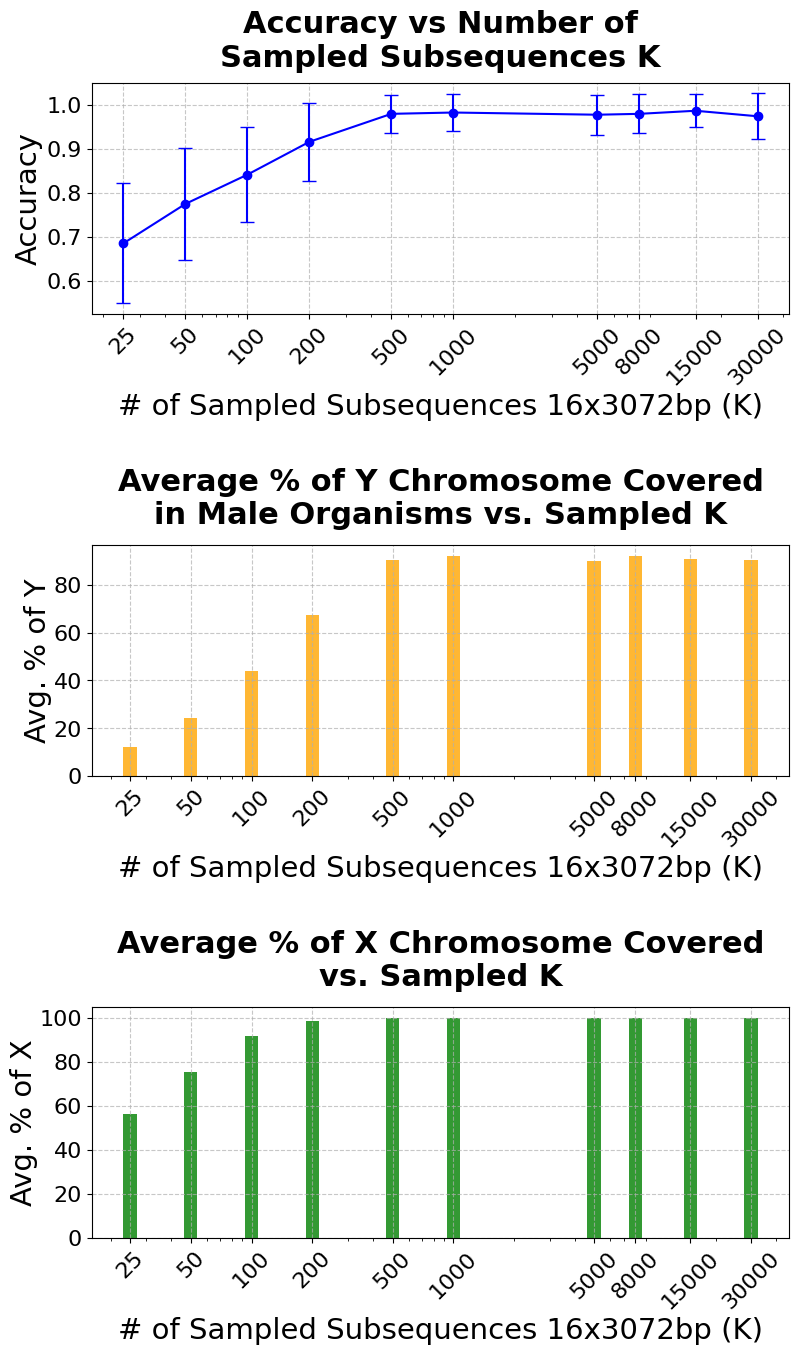

In [51]:
plot_error_bar(sample_ids_humans, list(N2thr.keys()), accs, stds, X_probs, Y_probs, species_names, chrX_ratio, chrY_ratio)

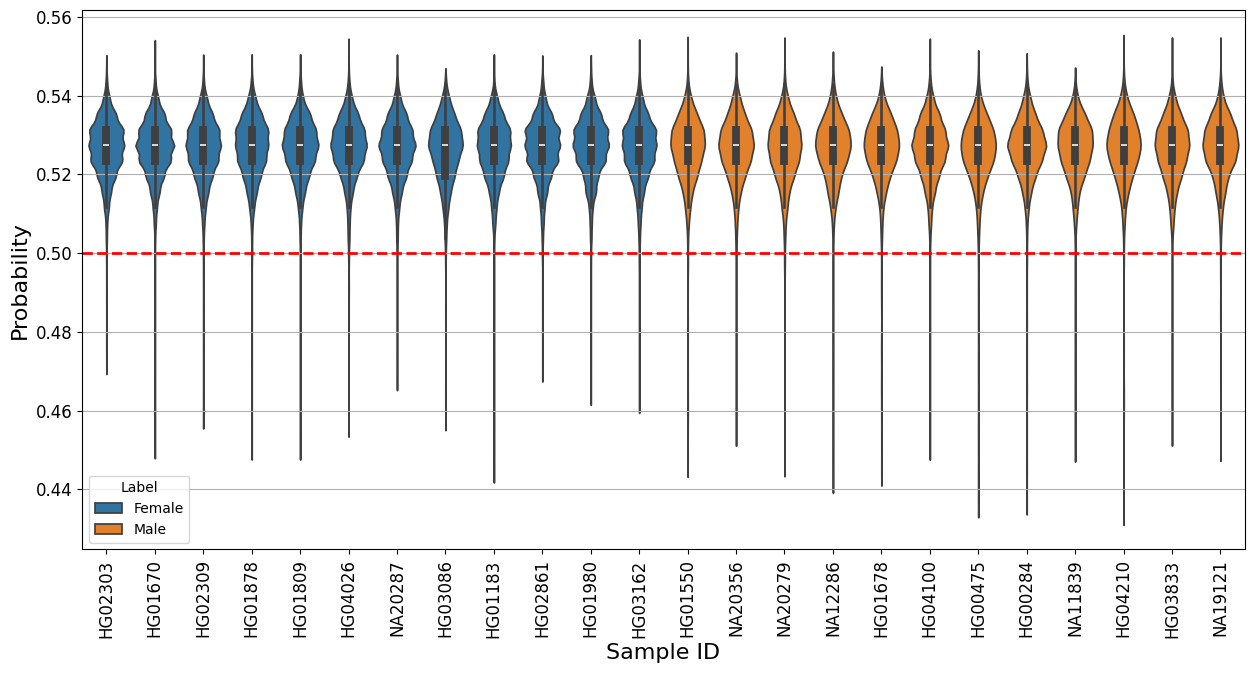

In [31]:
sample_ids_humans = {sample_id: label for sample_id, label in test_sample2labels.items() if sample_id in human_ids}
test_sample2probs_humans = {sample_id: prob for sample_id, prob in test_sample2probs.items() if sample_id in sample_ids_humans}

plot_violins(test_sample2probs_humans, sample_ids_humans, species_names, chrX_ratio, chrY_ratio)

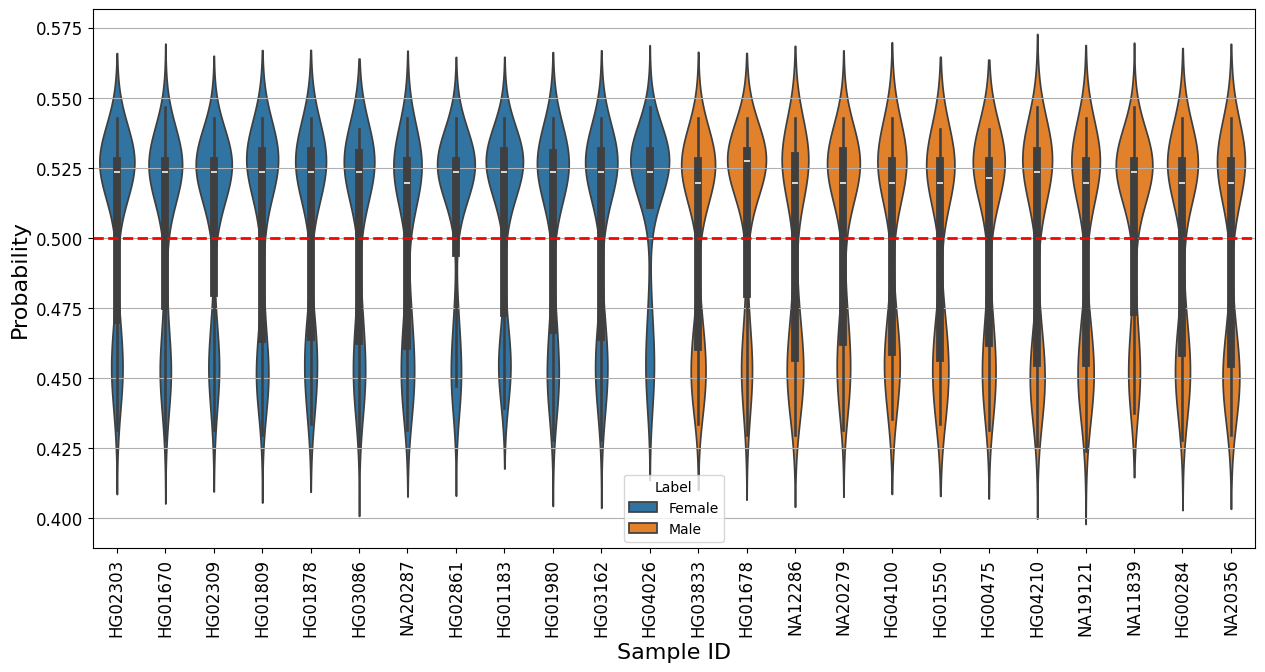

In [52]:
sample_ids_humans = {sample_id: label for sample_id, label in test_sample2labels.items() if sample_id in human_ids}
test_sample2probs_humans = {sample_id: prob for sample_id, prob in test_sample2probs.items() if sample_id in sample_ids_humans}

plot_violins(test_sample2probs_humans, sample_ids_humans, species_names, chrX_ratio, chrY_ratio)